## dataset
https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation

# **import library**

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model ,Sequential
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D
from tensorflow.keras.layers import MaxPooling2D, concatenate, Dense, Flatten ,UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-05-07 03:29:06.000709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778124546.218682      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778124546.286114      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778124546.803165      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778124546.803240      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778124546.803244      23 computation_placer.cc:177] computation placer alr

# *Read path of image*

In [2]:
# Set parameters
Size = (256, 256)
mask_files = glob('/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/*/*_mask*')
train_files = [file.replace('_mask', '') for file in mask_files]

**show 5 path of image**

In [3]:
mask_files[:5]

['/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_8_mask.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_34_mask.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33_mask.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_43_mask.tif']

**Show 5 path of mask**

In [4]:
train_files[:5]

['/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_8.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_34.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif',
 '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_43.tif']

**DataFrame of path iamge & mask & label**

In [5]:
def label(mask):
    value = np.max(cv2.imread(mask))
    return '1' if value > 0 else '0'
df = pd.DataFrame({"image": train_files,
                   "mask": mask_files,
                  "label":[label(x) for x in mask_files]})

**Show 5 row**

In [6]:
df.head()

,image,mask,label
0,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,0
1,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,0
2,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,1
3,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,1
4,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,1


**show Length of each class**

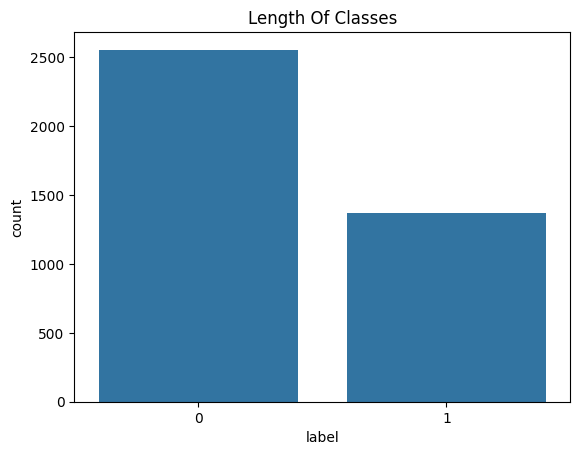

In [7]:
sns.countplot(data=df,x=df['label'])
plt.title('Length Of Classes')
plt.show()

**Take 5 row of each class**

In [8]:
df_Tumor = df[df['label']=='1'].sample(5).values
df_NotTumor = df[df['label']=='0'].sample(5).values

**Show row of Tumor**

In [9]:
df_Tumor[0]

array(['/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_HT_7608_19940304/TCGA_HT_7608_19940304_13.tif',
       '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_HT_7608_19940304/TCGA_HT_7608_19940304_13_mask.tif',
       '1'], dtype=object)

**Show row of Not Tumor**

In [10]:
df_NotTumor[0]

array(['/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_HT_7860_19960513/TCGA_HT_7860_19960513_2.tif',
       '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_HT_7860_19960513/TCGA_HT_7860_19960513_2_mask.tif',
       '0'], dtype=object)

# **Show image and Mask of each Class**

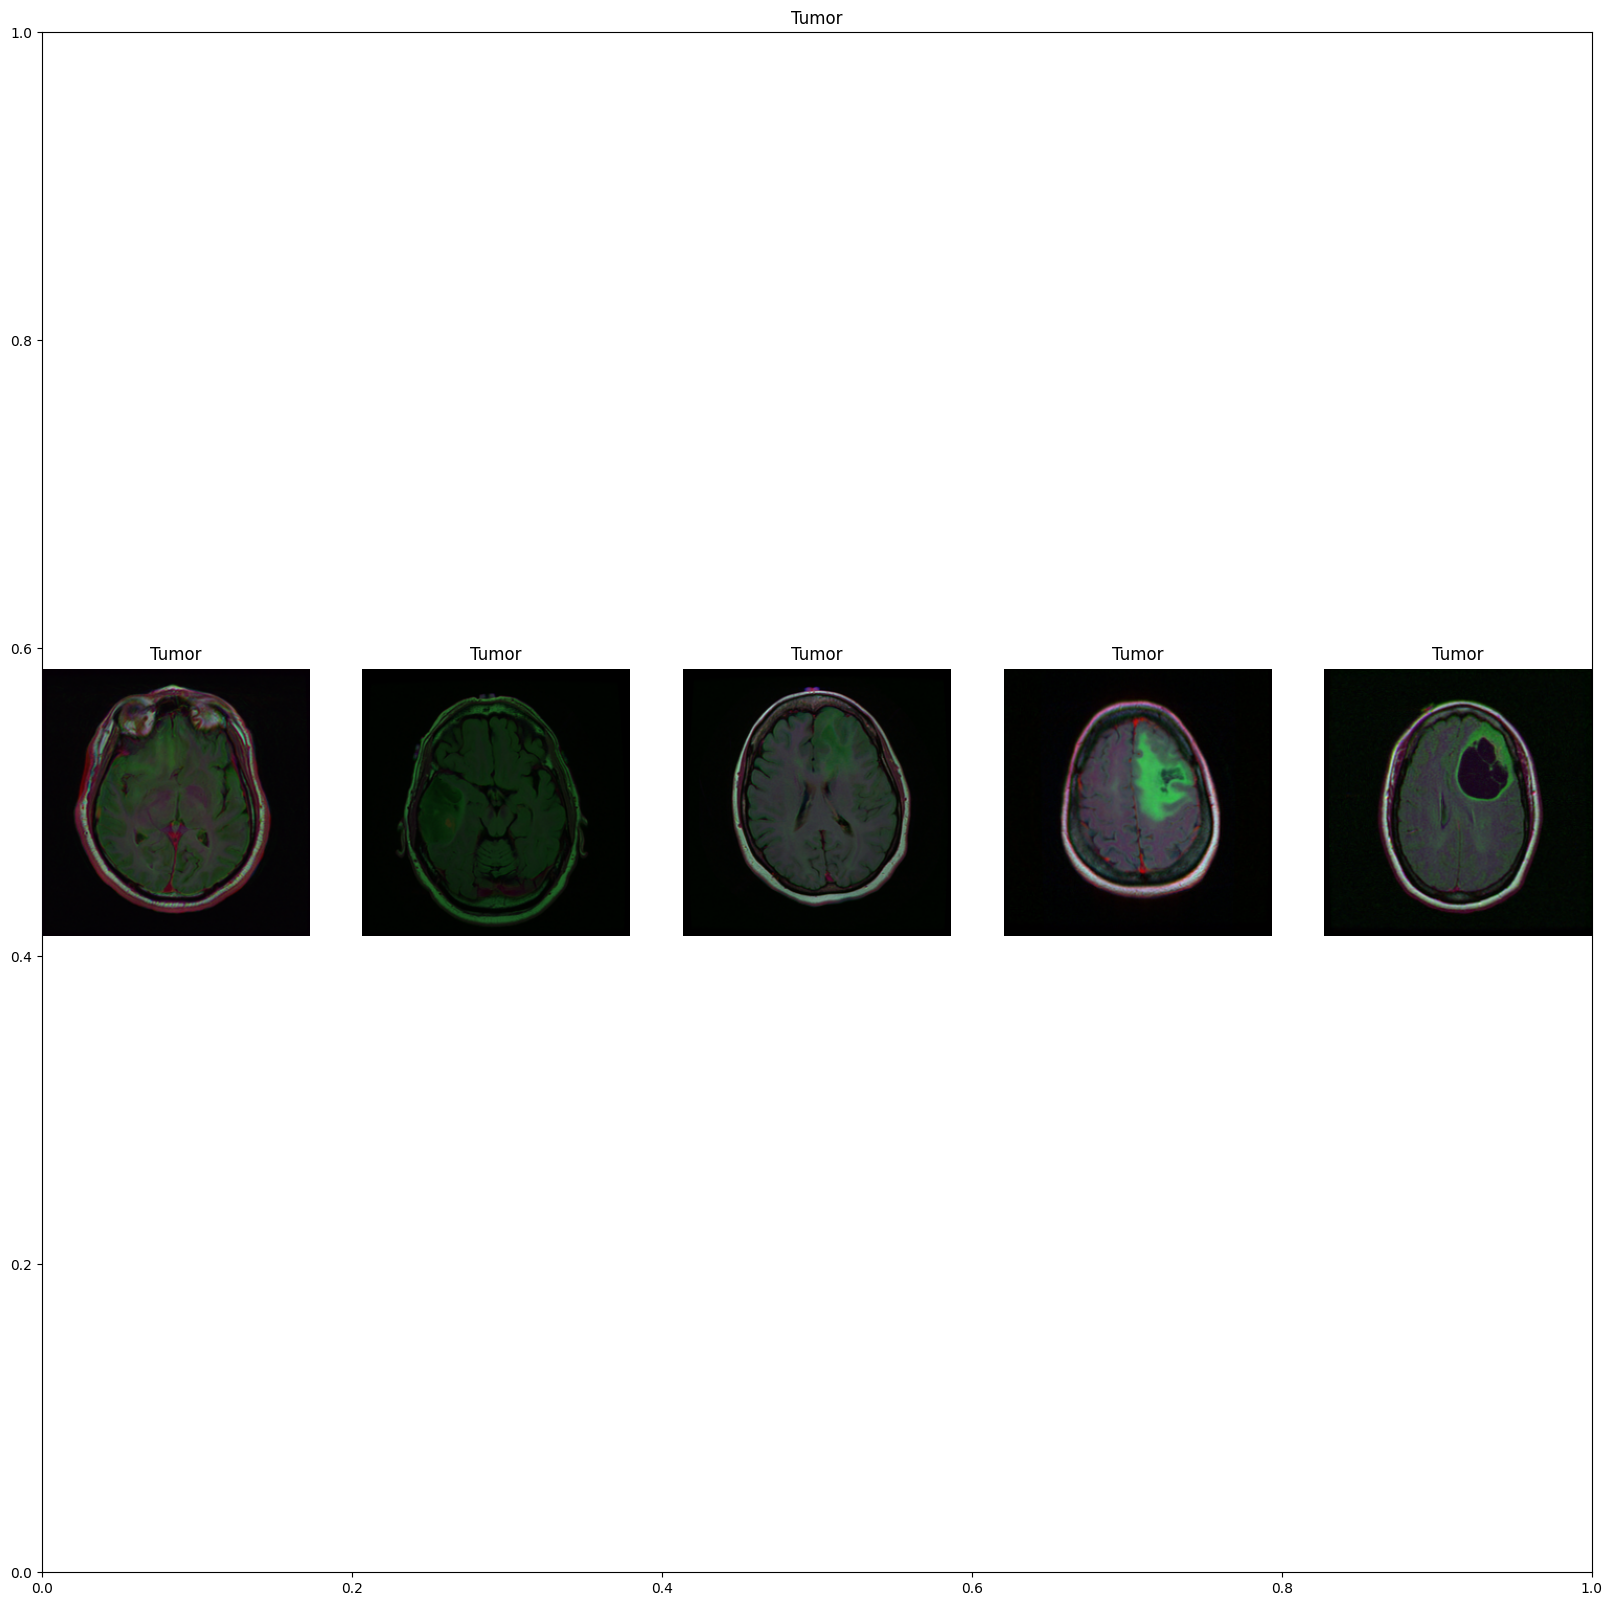

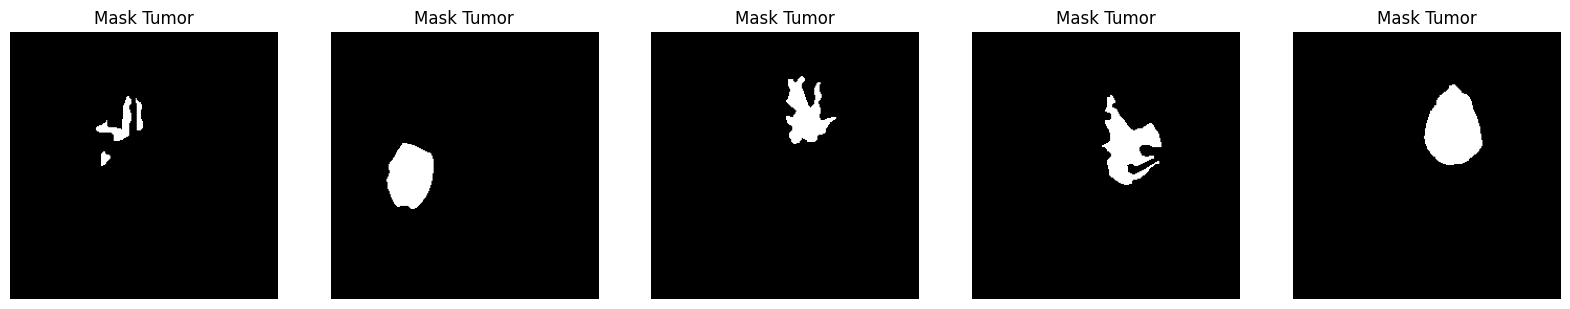

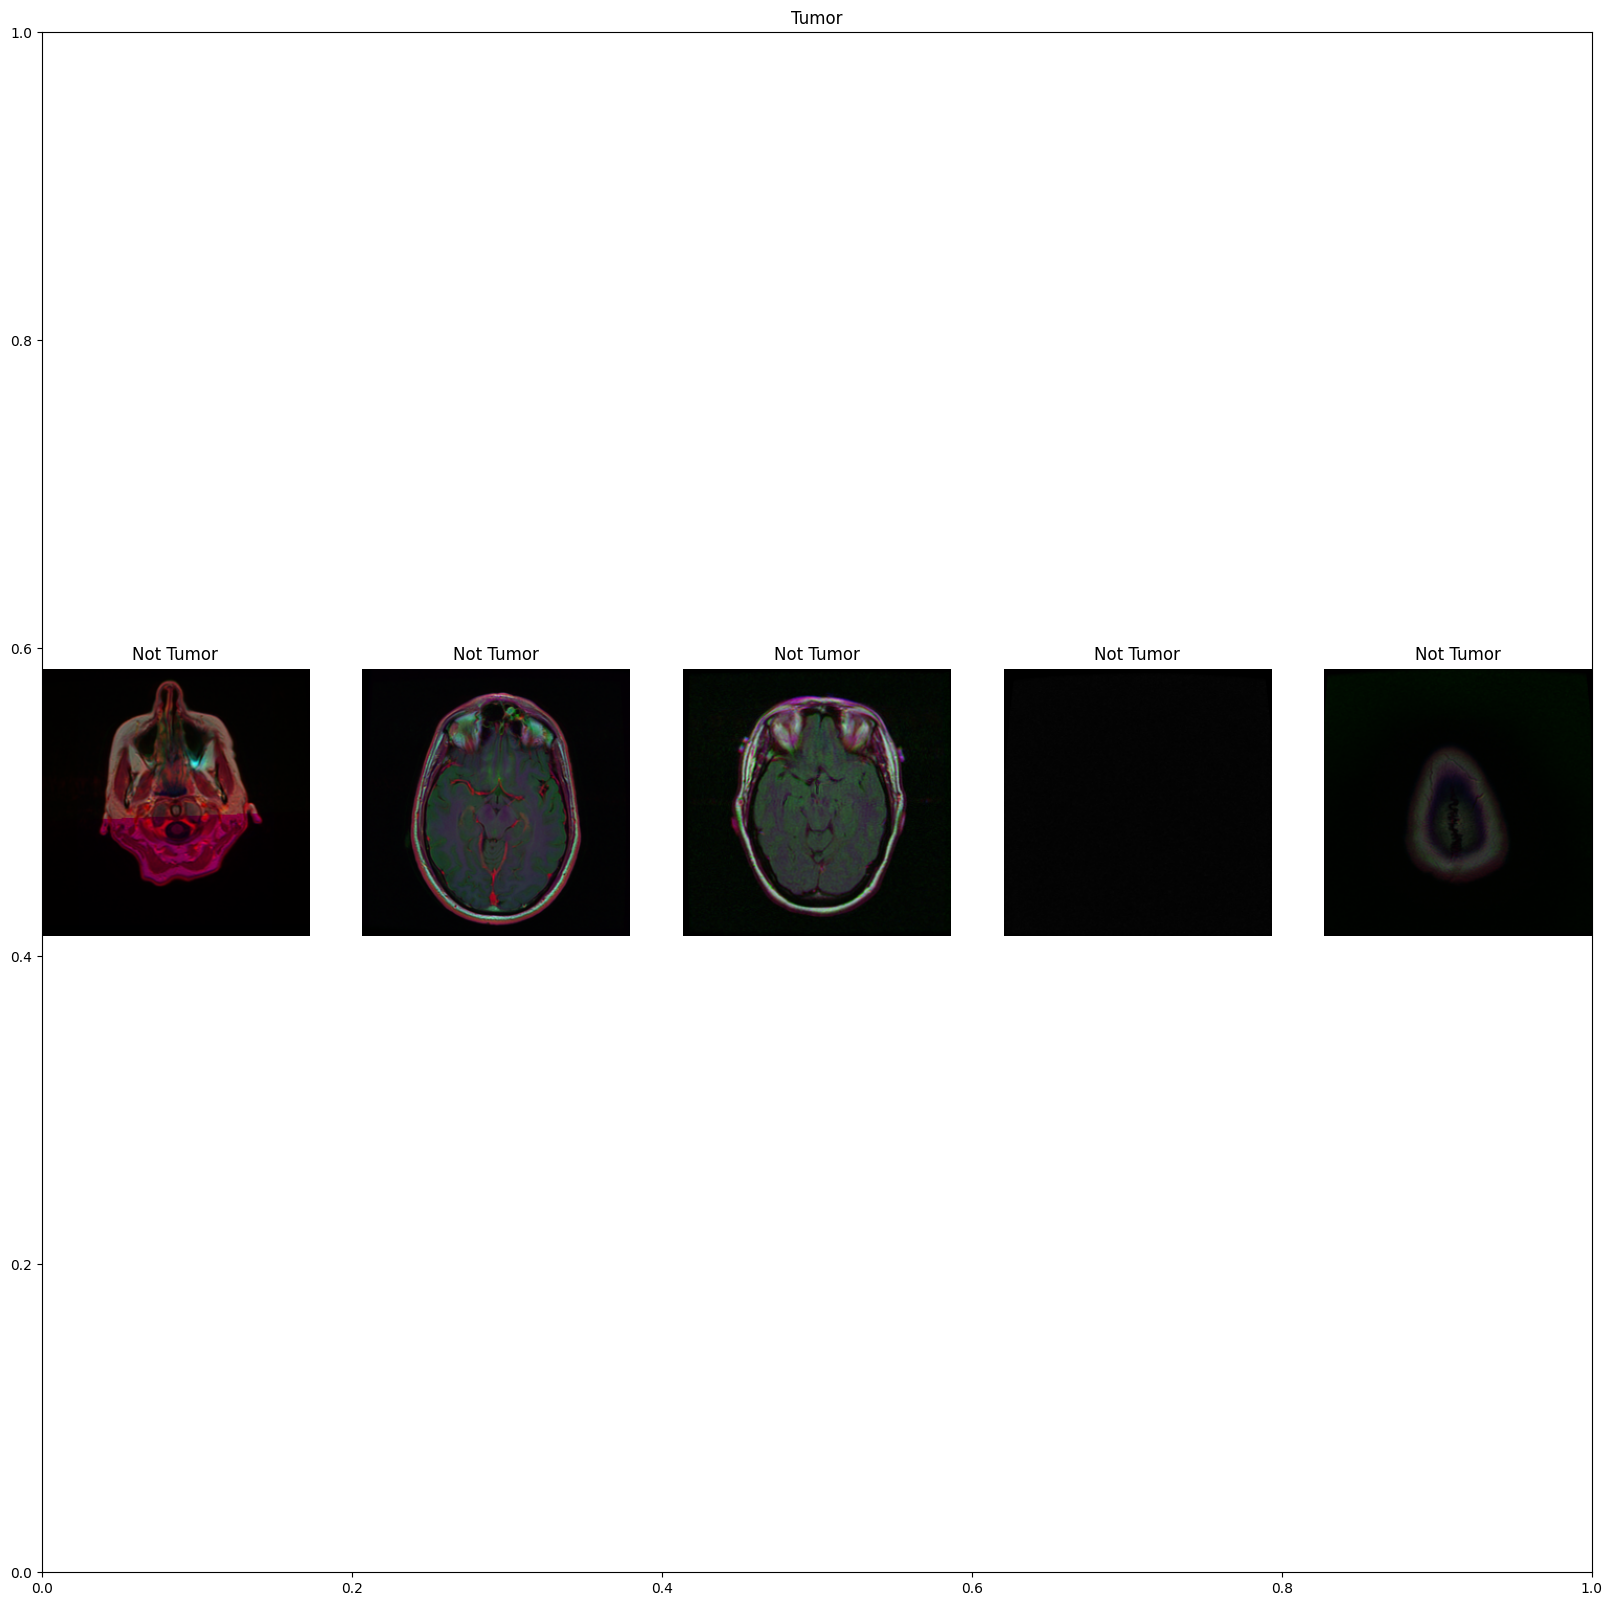

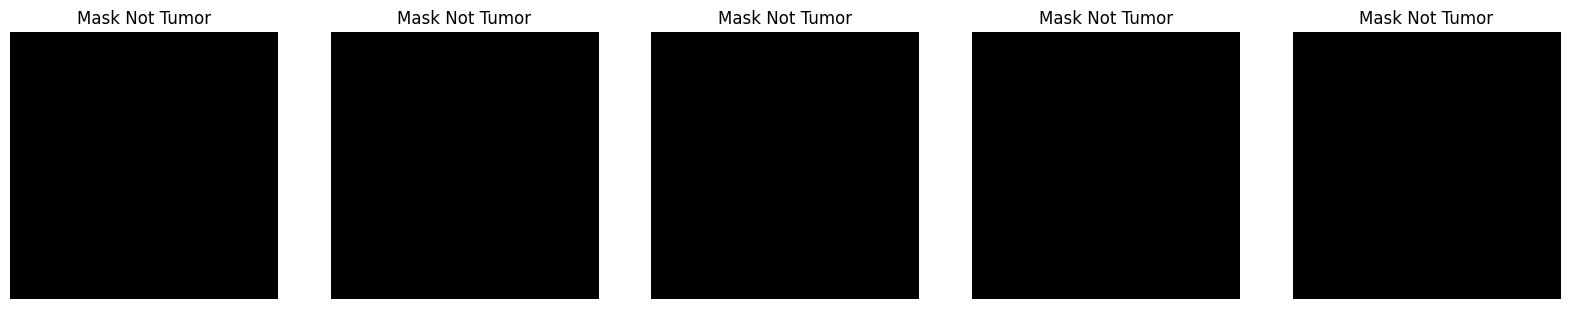

In [11]:
#showing training images with labels
plt.figure(figsize=(20,20))
plt.title('Tumor')
for n , i in enumerate(range(5)) :
    plt.subplot(1,5,n+1)
    img=cv2.imread(df_Tumor[i,0])
    plt.title('Tumor')
    plt.imshow(img)
    plt.axis('off')
    #showing training images with labels
plt.show()
plt.figure(figsize=(20,20))
for n , i in enumerate(range(5)) :
    plt.subplot(1,5,n+1)
    plt.title('Mask Tumor')
    img=cv2.imread(df_Tumor[i,1])
    plt.imshow(img)

    plt.axis('off')
plt.show()

#showing training images with labels
plt.figure(figsize=(20,20))
plt.title('Tumor')
for n , i in enumerate(range(5)) :
    plt.subplot(1,5,n+1)
    plt.title('Not Tumor')
    img=cv2.imread(df_NotTumor[i,0])
    plt.imshow(img)
    plt.axis('off')
    #showing training images with labels
plt.show()
plt.figure(figsize=(20,20))
for n , i in enumerate(range(5)) :
    plt.subplot(1,5,n+1)
    plt.title('Mask Not Tumor')
    img=cv2.imread(df_NotTumor[i,1])
    plt.imshow(img)

    plt.axis('off')
plt.show()

# **Split data train (0.9) valid (0.05) test (0.05)**

In [12]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.1)
df_test, df_val = train_test_split(df_test, test_size=0.5)
print(df_train.values.shape)
print(df_val.values.shape)
print(df_test.values.shape)

(3536, 3)
(197, 3)
(196, 3)


# **Function To augmentation and Scalling**

In [13]:
def train_generator(data_frame, batch_size, aug_dict,
        image_color_mode="rgb",
        mask_color_mode="grayscale",
        target_size=(256,256),
        seed=1):
    """Each batch: 75% tumor masks, 25% empty masks"""
    
    df_tumor  = df[df['label'] == '1'].reset_index(drop=True)
    df_empty  = df[df['label'] == '0'].reset_index(drop=True)
    
    n_tumor = max(1, int(batch_size * 0.75))   # e.g. 6 out of 8
    n_empty = batch_size - n_tumor              # e.g. 2 out of 8

    aug        = ImageDataGenerator(**aug_dict)
    aug_empty  = ImageDataGenerator(**{k: v for k, v in aug_dict.items()})

    def make_gen(dataframe, n, aug_obj):
        image_gen = aug_obj.flow_from_dataframe(
            dataframe, x_col='image', class_mode=None,
            color_mode='rgb', target_size=target_size,
            batch_size=n, seed=seed)
        mask_gen = aug_obj.flow_from_dataframe(
            dataframe, x_col='mask', class_mode=None,
            color_mode='grayscale', target_size=target_size,
            batch_size=n, seed=seed)
        return image_gen, mask_gen

    tumor_img_gen, tumor_mask_gen = make_gen(df_tumor, n_tumor, aug)
    empty_img_gen, empty_mask_gen = make_gen(df_empty, n_empty, aug_empty)

    def gen():
        for (t_img, t_mask), (e_img, e_mask) in zip(
            zip(tumor_img_gen, tumor_mask_gen),
            zip(empty_img_gen, empty_mask_gen)
        ):
            img  = np.concatenate([t_img,  e_img],  axis=0) / 255.
            mask = np.concatenate([t_mask, e_mask], axis=0) / 255.
            mask = (mask > 0.5).astype('float32')
            yield img, mask

    output_signature = (
        tf.TensorSpec(shape=(None, *target_size, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, *target_size, 1), dtype=tf.float32),
    )
    return tf.data.Dataset.from_generator(gen, output_signature=output_signature)

# 1.0 **Segmentation Model**

# 1.1 **Unet architecture**

In [14]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

In [15]:
def attention_block(x, g, filters):
    theta_x = Conv2D(filters, 1)(x)
    phi_g = Conv2D(filters, 1)(g)

    add = Activation('relu')(theta_x + phi_g)
    psi = Conv2D(1, 1, activation='sigmoid')(add)

    return Multiply()([x, psi])

In [16]:
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

In [17]:
def build_model(input_size=(256,256,3)):
    inputs = Input(input_size)

    # Encoder (ResNet-like simplified)
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D()(c4)

    # Bottleneck
    c5 = conv_block(p4, 1024)

    # Decoder + Attention
    u6 = Conv2DTranspose(512, 2, strides=2, padding='same')(c5)
    att6 = attention_block(c4, u6, 512)
    u6 = concatenate([u6, att6])
    c6 = conv_block(u6, 512)

    u7 = Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    att7 = attention_block(c3, u7, 256)
    u7 = concatenate([u7, att7])
    c7 = conv_block(u7, 256)

    u8 = Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    att8 = attention_block(c2, u8, 128)
    u8 = concatenate([u8, att8])
    c8 = conv_block(u8, 128)

    u9 = Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    att9 = attention_block(c1, u9, 64)
    u9 = concatenate([u9, att9])
    c9 = conv_block(u9, 64)

    outputs = Conv2D(1, 1, activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model

In [18]:
m=build_model()
m.summary()

I0000 00:00:1778124615.182906      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778124615.189085      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,754,501 (121.13 MB)

 Trainable params: 31,742,725 (121.09 MB)

 Non-trainable params: 11,776 (46.00 KB)

<img src="https://storage.googleapis.com/kaggle-media/competitions/rsna/IoU.jpg">
<img src="https://d3i71xaburhd42.cloudfront.net/8575e8beef47bd2880c92f54a749f933db983e56/2-Table1-1.png">



In [19]:
import tensorflow as tf
from tensorflow.keras import backend as K

smooth = 1.

def dice_coef(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        K.sum(y_true) + K.sum(y_pred) + smooth
    )


def dice_coef_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)


def iou(y_true, y_pred):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)


def combined_seg_loss(y_true, y_pred, 
                      alpha=0.7, beta=0.3, gamma=0.75,
                      w_bce=0.3, w_dice=0.3, w_tversky=0.4):
    """
    Weighted combination of BCE + Dice + Focal Tversky
    
    alpha  : Tversky penalty for False Negatives (higher = chase missed tumour)
    beta   : Tversky penalty for False Positives
    gamma  : Focal factor (higher = focus more on hard examples)
    w_*    : Weight of each loss component (must sum to 1.0)
    """

    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice_loss = 1 - (2. * intersection + smooth) / (
                    K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

    tp = K.sum(y_true_f * y_pred_f)
    fn = K.sum(y_true_f * (1 - y_pred_f))
    fp = K.sum((1 - y_true_f) * y_pred_f)
    tversky_index = (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)
    focal_tversky = K.pow(1 - tversky_index, gamma)

    return w_bce * bce + w_dice * dice_loss + w_tversky * focal_tversky

# **Parameters Of Fitiing**

In [20]:
# Set parameters
EPOCHS = 100
BATCH_SIZE = 8
learning_rate = 1e-4

# 1.2 **Read Data and augmentation**

In [21]:
train_generator_args = dict(rotation_range=15,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            horizontal_flip=True,
                            vertical_flip=True,
                            fill_mode='nearest')
train_gen = train_generator(df_train, BATCH_SIZE,
                                train_generator_args,
                                target_size=Size)
    
val_gen = train_generator(df_val, BATCH_SIZE,
                                dict(),
                                target_size=Size)

Found 1373 validated image filenames.
Found 1373 validated image filenames.
Found 2556 validated image filenames.
Found 2556 validated image filenames.
Found 1373 validated image filenames.
Found 1373 validated image filenames.
Found 2556 validated image filenames.
Found 2556 validated image filenames.


# 1.3 **Create Model Unet**

In [22]:
model = build_model()

**Optimization and CallBacks**

In [23]:
opt = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)

In [24]:
callbacks = [
    ModelCheckpoint('brainMRI_Segment.keras', save_best_only=True, monitor='val_dice_coef', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_dice_coef', patience=8, restore_best_weights=True, mode='max')
]

**Compile model**

In [25]:
model.compile(
    optimizer=opt,
    loss=combined_seg_loss,
    metrics=[iou, dice_coef]
)

**Fitting Model**

In [26]:
history = model.fit(train_gen,
                    steps_per_epoch=len(df_train) // BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=callbacks,
                    validation_data = val_gen,
                    validation_steps=len(df_val) // BATCH_SIZE)

Epoch 1/100


I0000 00:00:1778124649.363359      75 service.cc:152] XLA service 0x7c767c002400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778124649.363403      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778124649.363407      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778124652.190683      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 03:31:07.008650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:31:07.226051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:31:12.263748: E external/local_xl

228/442 ━━━━━━━━━━━━━━━━━━━━ 1:56 542ms/step - dice_coef: 0.1637 - iou: 0.0920 - loss: 0.6826

2026-05-07 03:33:54.481777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:33:54.710244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:33:55.680562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:33:55.989234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 03:34:07.110578: E external/local_xla/xla/stream_

442/442 ━━━━━━━━━━━━━━━━━━━━ 384s 709ms/step - dice_coef: 0.2154 - iou: 0.1255 - loss: 0.6226 - val_dice_coef: 0.3495 - val_iou: 0.2146 - val_loss: 0.4832 - learning_rate: 1.0000e-04
Epoch 2/100
442/442 ━━━━━━━━━━━━━━━━━━━━ 255s 577ms/step - dice_coef: 0.4863 - iou: 0.3283 - loss: 0.3860 - val_dice_coef: 0.6222 - val_iou: 0.4589 - val_loss: 0.2906 - learning_rate: 1.0000e-04
Epoch 3/100
442/442 ━━━━━━━━━━━━━━━━━━━━ 255s 577ms/step - dice_coef: 0.6537 - iou: 0.4937 - loss: 0.2757 - val_dice_coef: 0.6659 - val_iou: 0.5080 - val_loss: 0.2670 - learning_rate: 1.0000e-04
Epoch 4/100
442/442 ━━━━━━━━━━━━━━━━━━━━ 256s 578ms/step - dice_coef: 0.7392 - iou: 0.5948 - loss: 0.2207 - val_dice_coef: 0.7716 - val_iou: 0.6324 - val_loss: 0.1972 - learning_rate: 1.0000e-04
Epoch 5/100
442/442 ━━━━━━━━━━━━━━━━━━━━ 255s 576ms/step - dice_coef: 0.7689 - iou: 0.6341 - loss: 0.2033 - val_dice_coef: 0.8162 - val_iou: 0.6945 - val_loss: 0.1624 - learning_rate: 1.0000e-04
Epoch 6/100
442/442 ━━━━━━━━━━━━━━━━━

# 1.4 **visualization Accuracy and Loss**

Text(0.5, 1.0, 'Dice Coef')

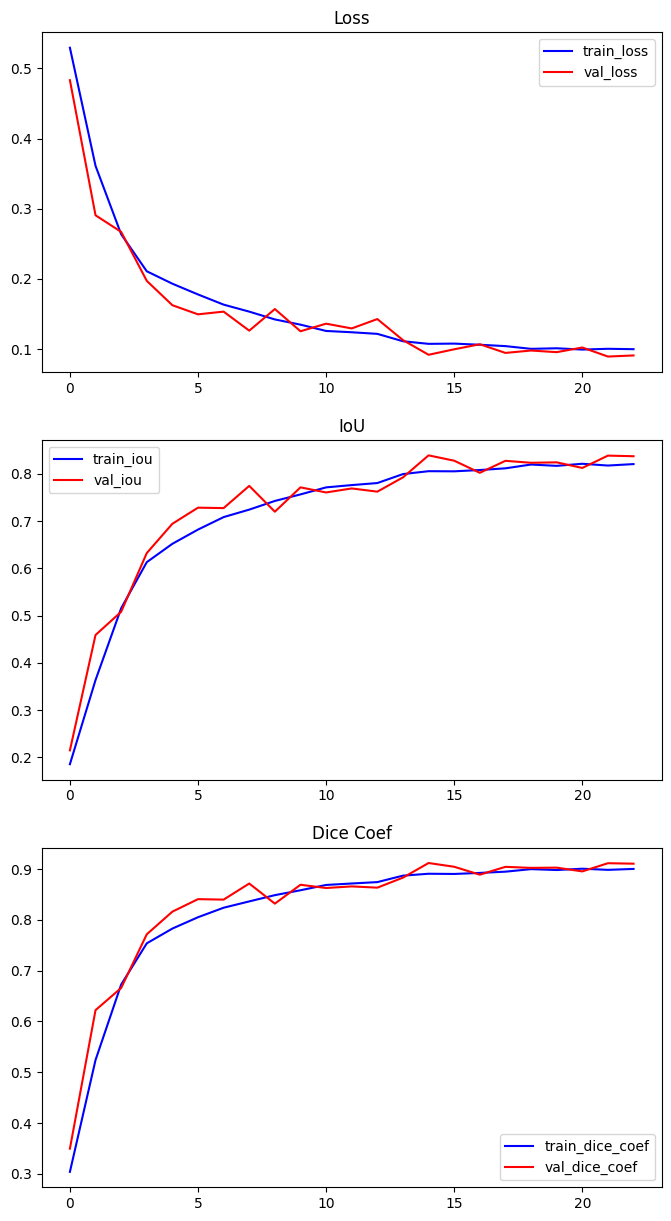

In [27]:
plt.figure(figsize=(8,15))
plt.subplot(3,1,1)
plt.plot(model.history.history['loss'], 'b-', label='train_loss')
plt.plot(model.history.history['val_loss'], 'r-', label='val_loss')
plt.legend(loc='best')
plt.title('Loss')

plt.subplot(3,1,2)
plt.plot(model.history.history['iou'], 'b-', label='train_iou')
plt.plot(model.history.history['val_iou'], 'r-', label='val_iou')
plt.legend(loc='best')
plt.title('IoU')

plt.subplot(3,1,3)
plt.plot(model.history.history['dice_coef'], 'b-', label='train_dice_coef')
plt.plot(model.history.history['val_dice_coef'], 'r-', label='val_dice_coef')
plt.legend(loc='best')
plt.title('Dice Coef')

# 1.5 **Predction**

In [ ]:
test_gen = train_generator(df_test, BATCH_SIZE,
                                dict(),
                                target_size=Size)
results = model.evaluate(test_gen, steps=len(df_test) / BATCH_SIZE)
print("Test IOU: ",results[1])
print("Test Dice Coefficent: ",results[2])

**visualization The prediction**

In [ ]:
for i in range(32):
    index=np.random.randint(1,len(df_test.index))
    img = cv2.imread(df_test['image'].iloc[index])
    img = cv2.resize(img ,Size)
    img = img / 255
    img = img[np.newaxis, :, :, :]
    pred=model.predict(img)

    plt.figure(figsize=(12,12))
    plt.subplot(1,3,1)
    plt.imshow(np.squeeze(img))
    plt.title('Original Image')
    plt.subplot(1,3,2)
    plt.imshow(np.squeeze(cv2.imread(df_test['mask'].iloc[index])))
    plt.title('Original Mask')
    plt.subplot(1,3,3)
    plt.imshow(np.squeeze(pred) > .5)
    plt.title('Prediction')
    plt.show()